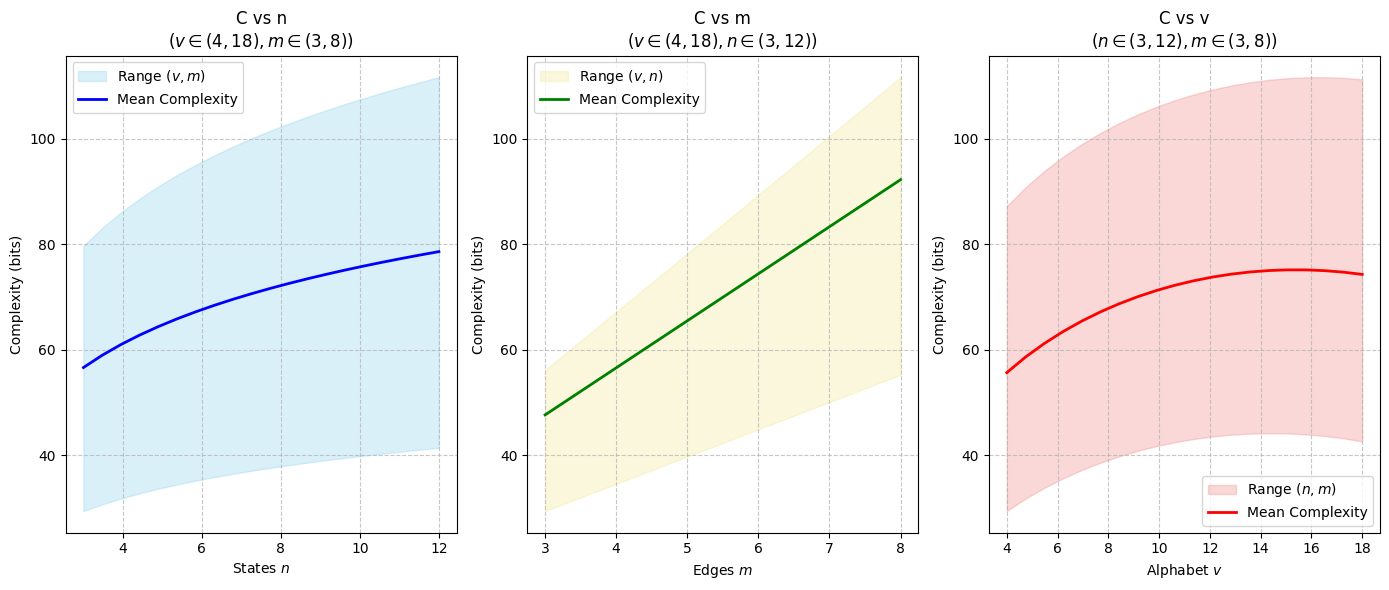

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb

def get_complexity(v, n, m, V=1000):
    log_binom = np.log2(comb(V, v))
    return log_binom + m * (2 * np.log2(n) + np.log2(v))

def plot_automaton_complexity(v_range=(4, 18), n_range=(3, 12), m_range=(1, 4), V=26):
    v_vals = np.linspace(v_range[0], v_range[1], 20)
    m_vals = np.linspace(m_range[0], m_range[1], 20)
    n_vals = np.linspace(n_range[0], n_range[1], 20)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 6))
    
    c_min, c_max, c_mean = [], [], []
    for n in n_vals:
        V_grid, M_grid = np.meshgrid(v_vals, m_vals)
        complexities = get_complexity(V_grid, n, M_grid, V)
        
        c_min.append(np.min(complexities))
        c_max.append(np.max(complexities))
        c_mean.append(np.mean(complexities))
    ax1.fill_between(n_vals, c_min, c_max, alpha=0.3, color='skyblue', label='Range ($v, m$)')
    ax1.plot(n_vals, c_mean, color='blue', lw=2, label='Mean Complexity')
    ax1.set_xlabel('States $n$')
    ax1.set_ylabel('Complexity (bits)')
    ax1.set_title(f'C vs n\n($v \in {v_range}, m \in {m_range}$)')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    c_min, c_max, c_mean = [], [], []
    for m in m_vals:
        N_grid, V_grid = np.meshgrid(n_vals, v_vals)
        complexities = get_complexity(V_grid, N_grid, m, V)
        
        c_min.append(np.min(complexities))
        c_max.append(np.max(complexities))
        c_mean.append(np.mean(complexities))
    ax2.fill_between(m_vals, c_min, c_max, alpha=0.3, color='khaki', label='Range ($v, n$)')
    ax2.plot(m_vals, c_mean, color='green', lw=2, label='Mean Complexity')
    ax2.set_xlabel('Edges $m$')
    ax2.set_ylabel('Complexity (bits)')
    ax2.set_title(f'C vs m\n($v \in {v_range}, n \in {n_range}$)')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    c_min, c_max, c_mean = [], [], []
    for v in v_vals:
        N_grid, M_grid = np.meshgrid(n_vals, m_vals)
        complexities = get_complexity(v, N_grid, M_grid, V)
        c_min.append(np.min(complexities))
        c_max.append(np.max(complexities))
        c_mean.append(np.mean(complexities))
    ax3.fill_between(v_vals, c_min, c_max, alpha=0.3, color='lightcoral', label='Range ($n, m$)')
    ax3.plot(v_vals, c_mean, color='red', lw=2, label='Mean Complexity')
    ax3.set_xlabel('Alphabet $v$')
    ax3.set_ylabel('Complexity (bits)')
    ax3.set_title(f'C vs v\n($n \in {n_range}, m \in {m_range}$)')
    ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.7)

    

    # # Subplot 2: Range Width Sensitivity
    # # Here we show how the width (max-min) behaves
    # width = np.array(c_max) - np.array(c_min)
    # ax2.plot(n_vals, width, color='red', lw=2)
    # ax2.set_xlabel('n')
    # ax2.set_ylabel('Complexity Range Width (bits)')
    # ax2.set_title('Uncertainty (Range Width) vs n')
    # ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# v_range: alphabet, n_range: states, m_range: edges
plot_automaton_complexity(m_range=(3,8))